In [26]:
# ==========================================================
# LIBRERÍAS
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("default")

BASE_DIR = Path.cwd().parent

DATA_PROCESSED = BASE_DIR / "data" / "processed"

In [27]:
# ==========================================================
# CARGA DATASET MAESTRO
# ==========================================================

df = pd.read_csv(
    DATA_PROCESSED / "dataset_maestro_granada_v2.csv"
)

print(df.shape)

df.head()

(128, 9)


,codigo_ine,municipio,poblacion_2025,superficie_residencial_m2,n_poligonos,superficie_media_poligono,precio_m2,fuente,anio
0,18905,"Gabias, Las",23584,3.682035e+06,1,3.682035e+06,NaN,NaN,NaN
1,18089,Guadix,18881,3.460928e+06,7,4.944182e+05,NaN,NaN,NaN
2,18022,Atarfe,20914,3.364040e+06,1,3.364040e+06,1369.0,Idealista,2026.0
3,18029,Benamaurel,2235,3.295178e+06,9,3.661309e+05,NaN,NaN,NaN
4,18003,Albolote,19768,2.949836e+06,1,2.949836e+06,NaN,NaN,NaN


In [28]:
# ==========================================================
# INFORMACIÓN GENERAL
# ==========================================================

df.info()

df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   codigo_ine                 128 non-null    int64  
 1   municipio                  128 non-null    object 
 2   poblacion_2025             128 non-null    int64  
 3   superficie_residencial_m2  128 non-null    float64
 4   n_poligonos                128 non-null    int64  
 5   superficie_media_poligono  128 non-null    float64
 6   precio_m2                  7 non-null      float64
 7   fuente                     7 non-null      object 
 8   anio                       7 non-null      float64
dtypes: float64(4), int64(3), object(2)
memory usage: 9.1+ KB


,codigo_ine,municipio,poblacion_2025,superficie_residencial_m2,n_poligonos,superficie_media_poligono,precio_m2,fuente,anio
count,128.000000,128,128.000000,1.280000e+02,128.000000,1.280000e+02,7.000000,7,7.0
unique,NaN,128,NaN,NaN,NaN,NaN,NaN,1,NaN
top,NaN,"Gabias, Las",NaN,NaN,NaN,NaN,NaN,Idealista,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,7,NaN
mean,18154.695312,NaN,4361.789062,6.603166e+05,2.695312,3.899484e+05,1640.285714,NaN,2026.0
std,227.088541,NaN,7679.283618,7.783636e+05,3.018470,5.996364e+05,825.821957,NaN,0.0
min,18001.000000,NaN,203.000000,2.672803e+04,1.000000,1.078619e+04,655.000000,NaN,2026.0
25%,18045.750000,NaN,674.500000,2.018424e+05,1.000000,9.821958e+04,1069.500000,NaN,2026.0
50%,18098.000000,NaN,1387.500000,3.642070e+05,1.000000,1.851634e+05,1491.000000,NaN,2026.0
75%,18150.250000,NaN,3901.250000,7.357848e+05,3.000000,3.727848e+05,2099.000000,NaN,2026.0


In [29]:
# ==========================================================
# NULOS
# ==========================================================

df.isnull().sum()

codigo_ine                     0
municipio                      0
poblacion_2025                 0
superficie_residencial_m2      0
n_poligonos                    0
superficie_media_poligono      0
precio_m2                    121
fuente                       121
anio                         121
dtype: int64

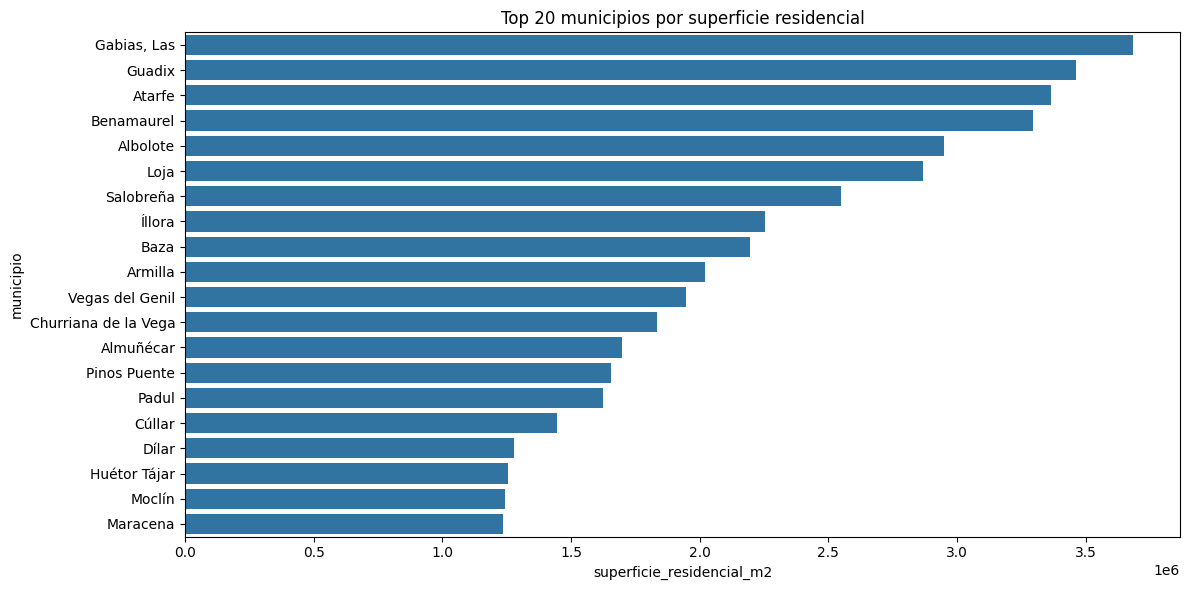

In [30]:
# ==========================================================
# TOP SUPERFICIE RESIDENCIAL
# ==========================================================

top_sup = (
    df
    .sort_values(
        "superficie_residencial_m2",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sup,
    x="superficie_residencial_m2",
    y="municipio"
)

plt.title(
    "Top 20 municipios por superficie residencial"
)

plt.tight_layout()
plt.show()

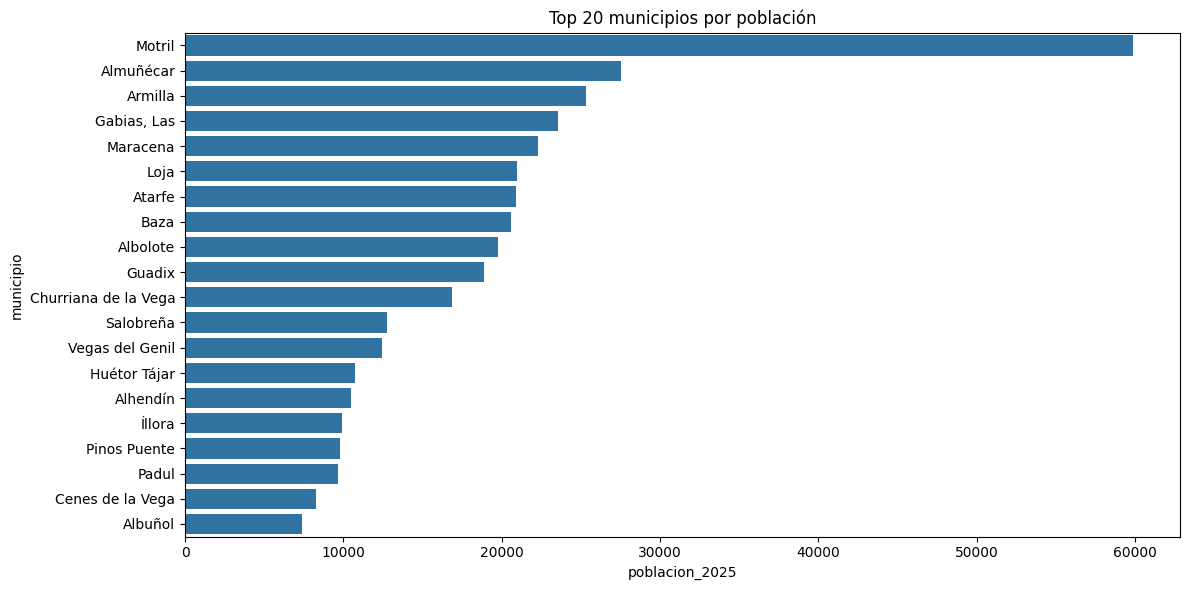

In [31]:
# ==========================================================
# TOP POBLACIÓN
# ==========================================================

top_pob = (
    df
    .sort_values(
        "poblacion_2025",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_pob,
    x="poblacion_2025",
    y="municipio"
)

plt.title(
    "Top 20 municipios por población"
)

plt.tight_layout()
plt.show()

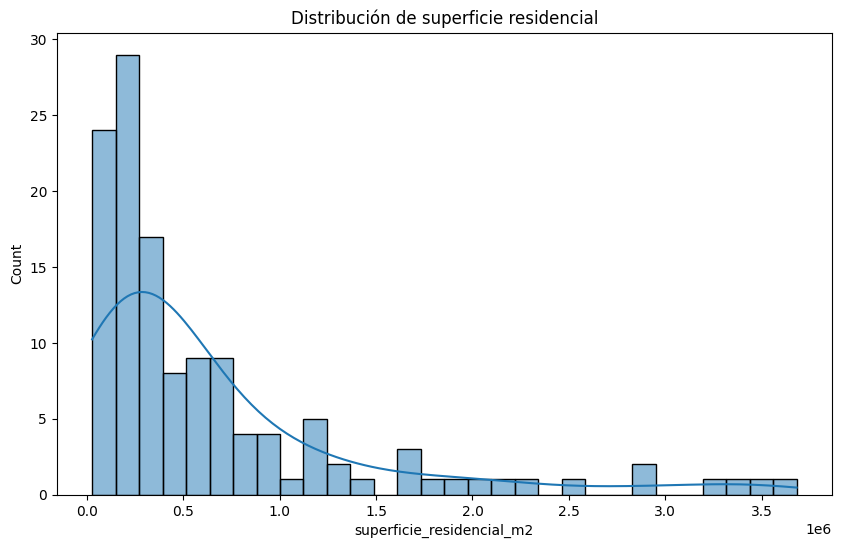

In [32]:
# ==========================================================
# DISTRIBUCIÓN SUPERFICIE
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["superficie_residencial_m2"],
    bins=30,
    kde=True
)

plt.title(
    "Distribución de superficie residencial"
)

plt.show()

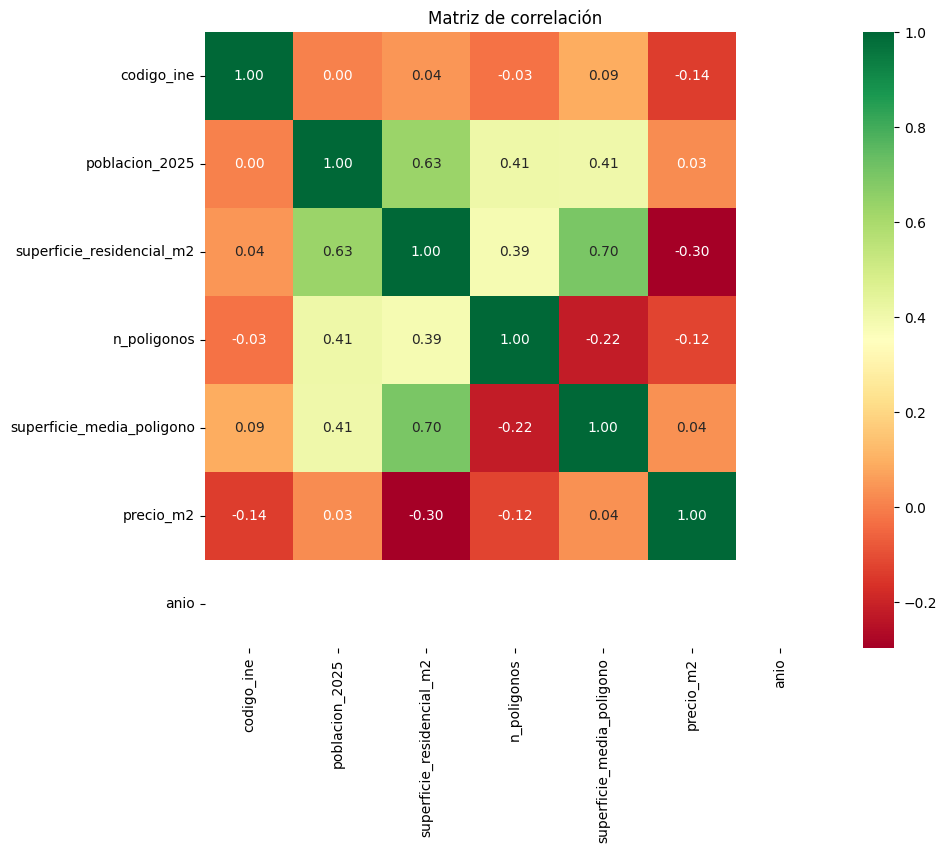

In [33]:
# ==========================================================
# CORRELACIONES
# ==========================================================

numericas = df.select_dtypes(
    include=["int64","float64"]
)

corr = numericas.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title(
    "Matriz de correlación"
)

plt.show()

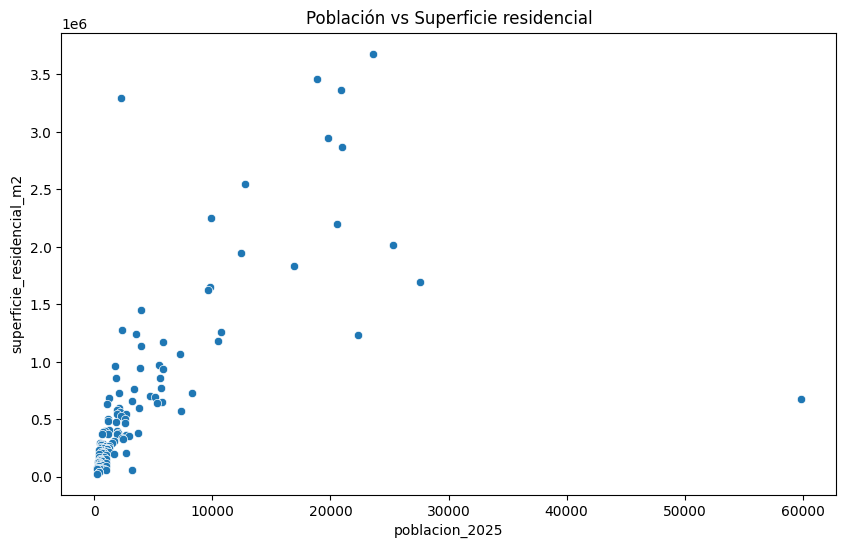

In [34]:
# ==========================================================
# POBLACIÓN VS SUELO
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="poblacion_2025",
    y="superficie_residencial_m2"
)

plt.title(
    "Población vs Superficie residencial"
)

plt.show()

In [35]:
df["superficie_residencial_ha"] = (
    df["superficie_residencial_m2"] / 10000
)

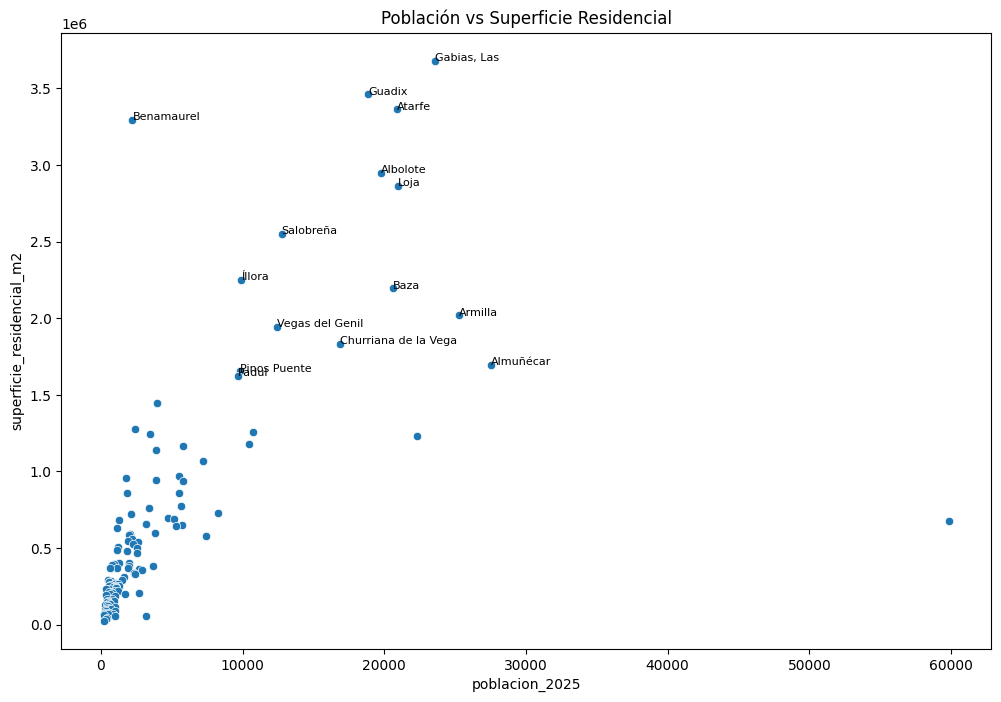

In [36]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="poblacion_2025",
    y="superficie_residencial_m2"
)

for _, row in (
    df.sort_values(
        "superficie_residencial_m2",
        ascending=False
    ).head(15).iterrows()
):
    plt.text(
        row["poblacion_2025"],
        row["superficie_residencial_m2"],
        row["municipio"],
        fontsize=8
    )

plt.title(
    "Población vs Superficie Residencial"
)

plt.show()

In [37]:
# ==========================================================
# CLUSTERING DE MUNICIPIOS
# ==========================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

variables = df[
    [
        "poblacion_2025",
        "superficie_residencial_m2",
        "n_poligonos"
    ]
]

scaler = StandardScaler()

X = scaler.fit_transform(variables)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

df["cluster"].value_counts()

cluster
1    94
0    17
2    14
3     3
Name: count, dtype: int64

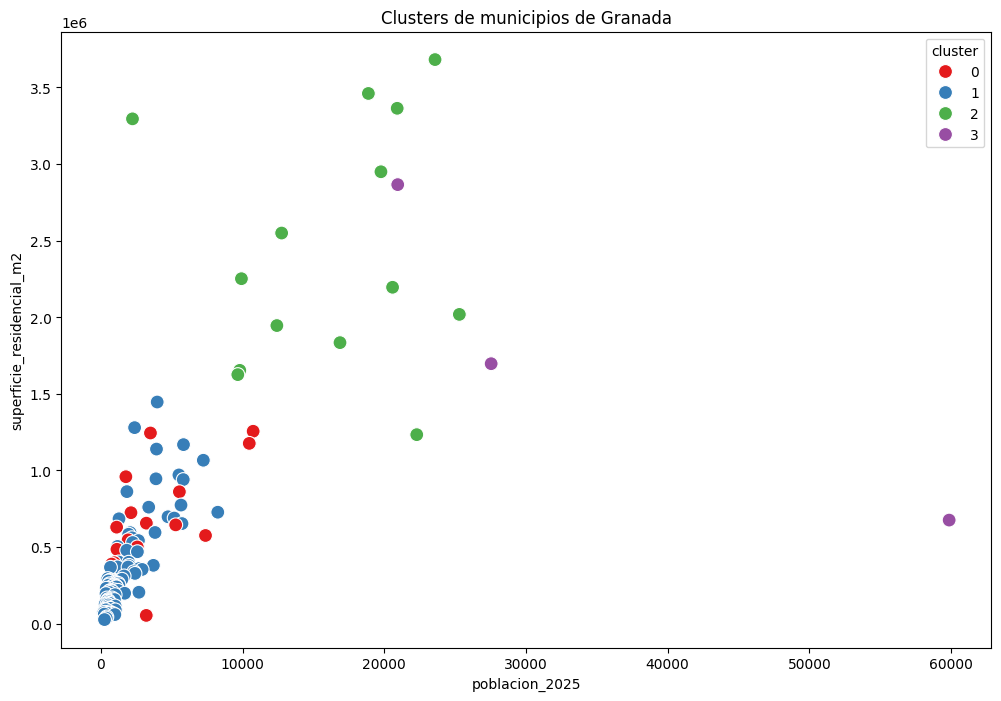

In [38]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="poblacion_2025",
    y="superficie_residencial_m2",
    hue="cluster",
    palette="Set1",
    s=100
)

plt.title(
    "Clusters de municipios de Granada"
)

plt.show()

In [39]:
df.groupby("cluster").agg({
    "poblacion_2025":["count","mean"],
    "superficie_residencial_m2":"mean",
    "n_poligonos":"mean"
}).round(2)

poblacion_2025           superficie_residencial_m2 n_poligonos
                 count      mean                      mean        mean
cluster                                                               
0                   17   3669.94                 665791.04        6.59
1                   94   1729.16                 360652.02        1.48
2                   14  16073.00                2432977.91        3.71
3                    3  36119.00                1746367.11       14.00

In [40]:
for c in sorted(df["cluster"].unique()):

    print("\n")
    print("="*50)
    print(f"CLUSTER {c}")
    print("="*50)

    display(
        df[df["cluster"] == c]
        .sort_values(
            "superficie_residencial_m2",
            ascending=False
        )
        [
            [
                "municipio",
                "poblacion_2025",
                "superficie_residencial_m2"
            ]
        ]
        .head(15)
    )



CLUSTER 0


,municipio,poblacion_2025,superficie_residencial_m2
17,Huétor Tájar,10749,1.256014e+06
18,Moclín,3503,1.244630e+06
20,Alhendín,10475,1.176891e+06
25,Cortes de Baza,1769,9.592263e+05
29,Alhama de Granada,5544,8.610316e+05
33,Valle del Zalabí,2128,7.244123e+05
38,Moraleda de Zafayona,3214,6.561312e+05
40,Montefrío,5283,6.449360e+05
41,Orce,1116,6.300045e+05
45,Albuñol,7388,5.756384e+05




CLUSTER 1


,municipio,poblacion_2025,superficie_residencial_m2
15,Cúllar,3978,1.446821e+06
16,Dílar,2384,1.279644e+06
21,Alfacar,5834,1.168743e+06
22,Caniles,3929,1.139734e+06
23,Dúrcal,7234,1.066738e+06
24,Cájar,5511,9.708684e+05
26,Láchar,3892,9.455759e+05
27,Chauchina,5817,9.405808e+05
28,Cuevas del Campo,1841,8.619906e+05
30,Pulianas,5659,7.742150e+05




CLUSTER 2


,municipio,poblacion_2025,superficie_residencial_m2
0,"Gabias, Las",23584,3.682035e+06
1,Guadix,18881,3.460928e+06
2,Atarfe,20914,3.364040e+06
3,Benamaurel,2235,3.295178e+06
4,Albolote,19768,2.949836e+06
6,Salobreña,12760,2.549806e+06
7,Íllora,9923,2.251832e+06
8,Baza,20587,2.195843e+06
9,Armilla,25300,2.018746e+06
10,Vegas del Genil,12424,1.945911e+06




CLUSTER 3


,municipio,poblacion_2025,superficie_residencial_m2
5,Loja,20951,2.865888e+06
12,Almuñécar,27544,1.697003e+06
37,Motril,59862,6.762105e+05


In [41]:
df["suelo_por_habitante"] = (
    df["superficie_residencial_m2"]
    / df["poblacion_2025"]
)

df.sort_values(
    "suelo_por_habitante",
    ascending=False
)[
    [
        "municipio",
        "poblacion_2025",
        "superficie_residencial_m2",
        "suelo_por_habitante"
    ]
].head(20)

,municipio,poblacion_2025,superficie_residencial_m2,suelo_por_habitante
3,Benamaurel,2235,3.295178e+06,1474.352704
87,Dehesas de Guadix,382,2.309216e+05,604.506878
69,Villanueva de las Torres,491,2.941682e+05,599.120481
41,Orce,1116,6.300045e+05,564.520161
25,Cortes de Baza,1769,9.592263e+05,542.242130
63,"Calahorra, La",680,3.680019e+05,541.179273
16,Dílar,2384,1.279644e+06,536.763325
36,Castilléjar,1284,6.847006e+05,533.255933
97,Gorafe,368,1.961912e+05,533.128151
73,Alquife,543,2.784168e+05,512.738104


In [42]:
# ==========================================================
# SUELO RESIDENCIAL POR HABITANTE
# ==========================================================

df["suelo_por_habitante"] = (
    df["superficie_residencial_m2"]
    / df["poblacion_2025"]
)

df[
    [
        "municipio",
        "poblacion_2025",
        "superficie_residencial_m2",
        "suelo_por_habitante"
    ]
].head()

,municipio,poblacion_2025,superficie_residencial_m2,suelo_por_habitante
0,"Gabias, Las",23584,3.682035e+06,156.124271
1,Guadix,18881,3.460928e+06,183.302140
2,Atarfe,20914,3.364040e+06,160.851083
3,Benamaurel,2235,3.295178e+06,1474.352704
4,Albolote,19768,2.949836e+06,149.222761


In [43]:
# ==========================================================
# NORMALIZACIÓN
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["score_poblacion"] = scaler.fit_transform(
    df[["poblacion_2025"]]
)

df["score_superficie"] = scaler.fit_transform(
    df[["superficie_residencial_m2"]]
)

df["score_suelo_hab"] = scaler.fit_transform(
    df[["suelo_por_habitante"]]
)

In [44]:
# ==========================================================
# COOPSCORE V1
# ==========================================================

df["coopscore_v1"] = (

    df["score_superficie"] * 0.40 +

    df["score_suelo_hab"] * 0.30 +

    df["score_poblacion"] * 0.30

) * 100

df[
    [
        "municipio",
        "coopscore_v1"
    ]
].sort_values(
    "coopscore_v1",
    ascending=False
).head(20)

,municipio,coopscore_v1
3,Benamaurel,66.788439
0,"Gabias, Las",54.727024
1,Guadix,50.499792
2,Atarfe,50.001496
4,Albolote,44.654150
5,Loja,44.075460
6,Salobreña,37.790266
37,Motril,37.107283
8,Baza,35.942339
9,Armilla,35.823385


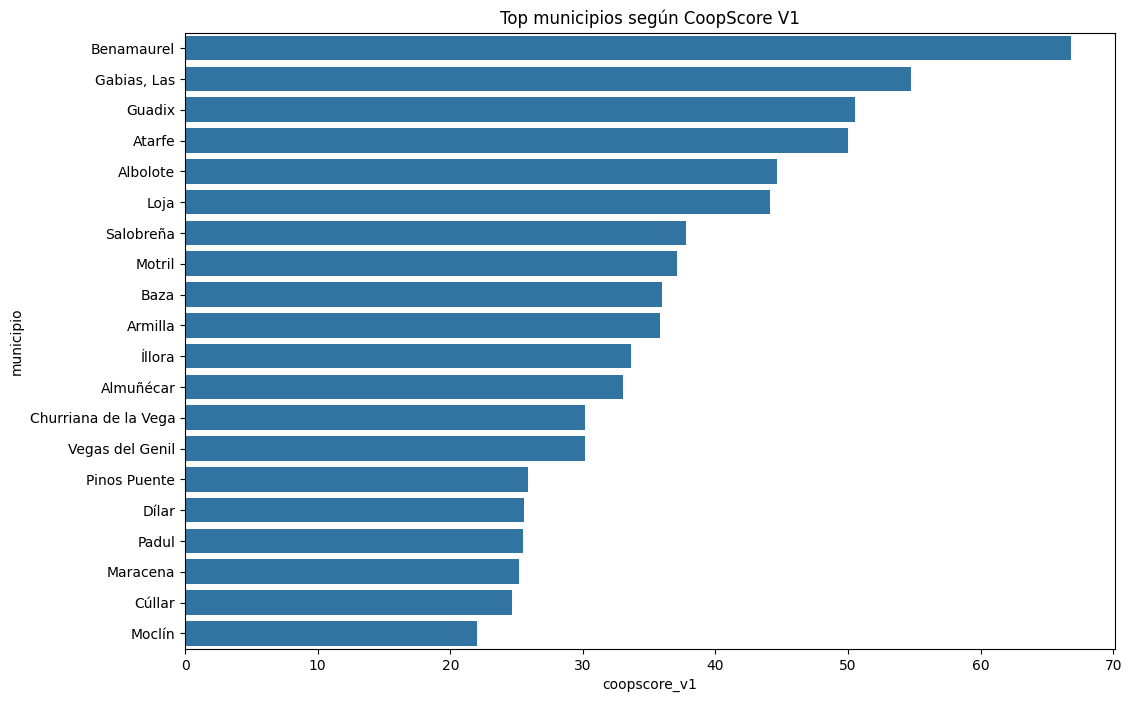

In [45]:
# ==========================================================
# TOP 20 COOPSCORE
# ==========================================================

top_score = (

    df
    .sort_values(
        "coopscore_v1",
        ascending=False
    )
    .head(20)

)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_score,
    x="coopscore_v1",
    y="municipio"
)

plt.title(
    "Top municipios según CoopScore V1"
)

plt.show()

In [46]:
def clasificar(score):

    if score >= 75:
        return "Alta"

    elif score >= 50:
        return "Media"

    else:
        return "Baja"

df["oportunidad"] = df["coopscore_v1"].apply(clasificar)

In [47]:
df[
    [
        "municipio",
        "poblacion_2025",
        "superficie_residencial_m2",
        "suelo_por_habitante",
        "coopscore_v1",
        "cluster"
    ]
].sort_values(
    "coopscore_v1",
    ascending=False
).head(20)

,municipio,poblacion_2025,superficie_residencial_m2,suelo_por_habitante,coopscore_v1,cluster
3,Benamaurel,2235,3.295178e+06,1474.352704,66.788439,2
0,"Gabias, Las",23584,3.682035e+06,156.124271,54.727024,2
1,Guadix,18881,3.460928e+06,183.302140,50.499792,2
2,Atarfe,20914,3.364040e+06,160.851083,50.001496,2
4,Albolote,19768,2.949836e+06,149.222761,44.654150,2
5,Loja,20951,2.865888e+06,136.790031,44.075460,3
6,Salobreña,12760,2.549806e+06,199.828073,37.790266,2
37,Motril,59862,6.762105e+05,11.296156,37.107283,3
8,Baza,20587,2.195843e+06,106.661635,35.942339,2
9,Armilla,25300,2.018746e+06,79.792345,35.823385,2


In [48]:
# ==========================================================
# LOG POBLACIÓN
# ==========================================================

df["log_poblacion"] = np.log1p(df["poblacion_2025"])

In [49]:
# ==========================================================
# NORMALIZACIÓN LOG POBLACIÓN
# ==========================================================

df["score_log_poblacion"] = scaler.fit_transform(
    df[["log_poblacion"]]
)

In [50]:
# ==========================================================
# COOPSCORE V2
# ==========================================================

df["coopscore_v2"] = (

    df["score_superficie"] * 0.35 +

    df["score_suelo_hab"] * 0.25 +

    df["score_log_poblacion"] * 0.40

) * 100

In [51]:
(
    df[
        [
            "municipio",
            "poblacion_2025",
            "coopscore_v2"
        ]
    ]
    .sort_values(
        "coopscore_v2",
        ascending=False
    )
    .head(20)
)

,municipio,poblacion_2025,coopscore_v2
3,Benamaurel,2235,73.152211
0,"Gabias, Las",23584,70.917217
1,Guadix,18881,67.698749
2,Atarfe,20914,67.107310
4,Albolote,19768,62.545834
5,Loja,20951,61.938748
6,Salobreña,12760,56.498598
8,Baza,20587,54.884785
9,Armilla,25300,54.181159
7,Íllora,9923,52.338413


In [52]:
# ==========================================================
# PCA
# ==========================================================

from sklearn.decomposition import PCA

features = df[
    [
        "poblacion_2025",
        "superficie_residencial_m2",
        "n_poligonos"
    ]
]

X_scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)

componentes = pca.fit_transform(X_scaled)

df["PCA1"] = componentes[:,0]
df["PCA2"] = componentes[:,1]

print(
    pca.explained_variance_ratio_
)

[0.65387642 0.22455989]


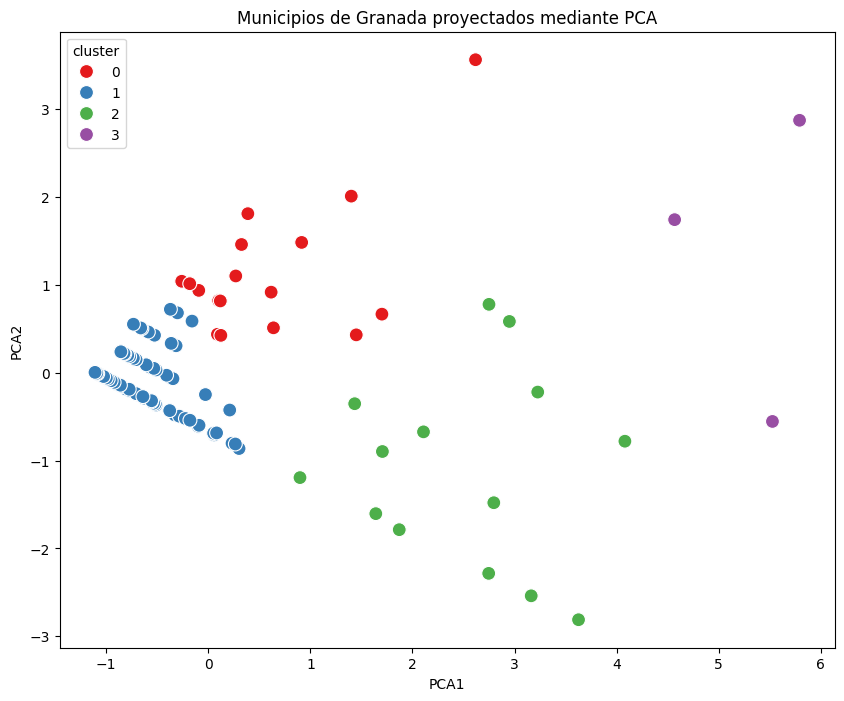

In [53]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="cluster",
    palette="Set1",
    s=100
)

plt.title(
    "Municipios de Granada proyectados mediante PCA"
)

plt.show()

In [54]:
def clasificar(score):

    if score >= 70:
        return "Alta"

    elif score >= 40:
        return "Media"

    else:
        return "Baja"

df["oportunidad"] = (
    df["coopscore_v2"]
    .apply(clasificar)
)

In [55]:
df["oportunidad"].value_counts()

oportunidad
Baja     108
Media     18
Alta       2
Name: count, dtype: int64

In [56]:
df.to_csv(
    DATA_PROCESSED / "dataset_modelado.csv",
    index=False
)

print("Dataset modelado guardado")

Dataset modelado guardado


In [57]:
df["objetivo_ml"] = (

    df["score_superficie"] * 0.40 +

    df["score_log_poblacion"] * 0.35 +

    df["score_suelo_hab"] * 0.25

)

In [58]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "poblacion_2025",
    "superficie_residencial_m2",
    "n_poligonos",
    "suelo_por_habitante"
]

X = df[features]
y = df["objetivo_ml"]

modelo = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo.fit(X,y)

importancias = pd.DataFrame({
    "variable":features,
    "importancia":modelo.feature_importances_
})

importancias.sort_values(
    "importancia",
    ascending=False
)

,variable,importancia
1,superficie_residencial_m2,0.907460
0,poblacion_2025,0.086598
3,suelo_por_habitante,0.003697
2,n_poligonos,0.002246


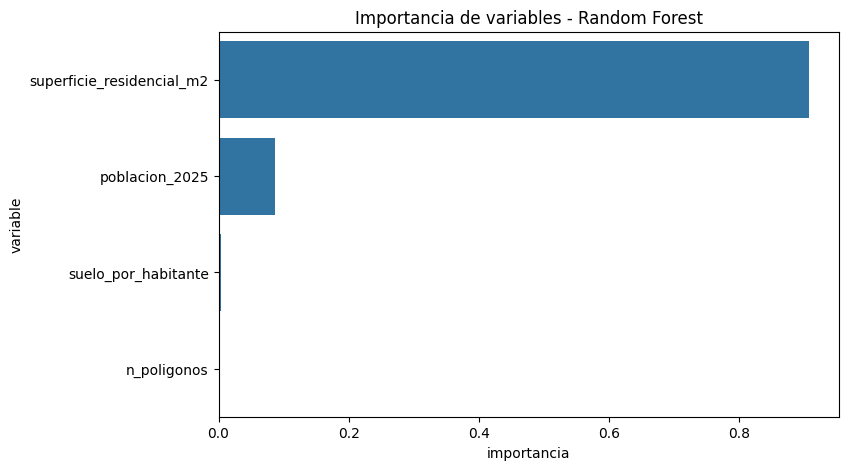

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importancias.sort_values(
        "importancia",
        ascending=False
    ),
    x="importancia",
    y="variable"
)

plt.title(
    "Importancia de variables - Random Forest"
)

plt.show()

In [60]:
importancias.sort_values(
    "importancia",
    ascending=False
)

,variable,importancia
1,superficie_residencial_m2,0.907460
0,poblacion_2025,0.086598
3,suelo_por_habitante,0.003697
2,n_poligonos,0.002246


In [61]:
df["densidad_residencial"] = (
    df["superficie_residencial_m2"]
    / df["n_poligonos"]
)

In [62]:
df[
    [
        "municipio",
        "cluster",
        "coopscore_v2",
        "densidad_residencial"
    ]
].head()

,municipio,cluster,coopscore_v2,densidad_residencial
0,"Gabias, Las",2,70.917217,3.682035e+06
1,Guadix,2,67.698749,4.944182e+05
2,Atarfe,2,67.107310,3.364040e+06
3,Benamaurel,2,73.152211,3.661309e+05
4,Albolote,2,62.545834,2.949836e+06


In [63]:
df.to_csv(
    DATA_PROCESSED / "dataset_modelado_v2.csv",
    index=False
)